In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
 
print("All libraries imported successfully!")


All libraries imported successfully!


In [23]:
data = {
    'Name':    ['Alice', 'Bob', 'Charlie', 'David', 'Eva',
                'Frank', 'Grace', 'Heidi', 'Ivan', 'Judy'],
    'Age':     [25, np.nan, 35, 28, np.nan, 42, 31, 26, np.nan, 38],
    'Salary':  [50000, 62000, np.nan, 45000, 70000,
                np.nan, 55000, 48000, 60000, np.nan],
    'Gender':  ['Female','Male','Male','Male','Female',
                'Male','Female','Female','Male','Female'],
    'Country': ['India','USA','UK','India','USA',
                'UK','India','USA','UK','India'],
    'Purchased': ['Yes','No','Yes','No','Yes',
                  'No','Yes','No','Yes','No']
}
df = pd.DataFrame(data)
orig_missing = df.copy()
print(df)


      Name   Age   Salary  Gender Country Purchased
0    Alice  25.0  50000.0  Female   India       Yes
1      Bob   NaN  62000.0    Male     USA        No
2  Charlie  35.0      NaN    Male      UK       Yes
3    David  28.0  45000.0    Male   India        No
4      Eva   NaN  70000.0  Female     USA       Yes
5    Frank  42.0      NaN    Male      UK        No
6    Grace  31.0  55000.0  Female   India       Yes
7    Heidi  26.0  48000.0  Female     USA        No
8     Ivan   NaN  60000.0    Male      UK       Yes
9     Judy  38.0      NaN  Female   India        No


In [24]:
# Missing values before treatment
print("Missing Values:\n", df.isnull().sum())
 
# Fill Age with mean
df['Age'] = df['Age'].fillna(round(df['Age'].mean(), 1))
 
# Fill Salary with median
df['Salary'] = df['Salary'].fillna(df['Salary'].median())
 
print("\nAfter filling — Missing Values:\n", df.isnull().sum())


Missing Values:
 Name         0
Age          3
Salary       3
Gender       0
Country      0
Purchased    0
dtype: int64

After filling — Missing Values:
 Name         0
Age          0
Salary       0
Gender       0
Country      0
Purchased    0
dtype: int64


In [25]:
le = LabelEncoder()
df['Gender_Enc']    = le.fit_transform(df['Gender'])
df['Purchased_Enc'] = le.fit_transform(df['Purchased'])
df = pd.get_dummies(df, columns=['Country'], prefix='Country')
print(df[['Name','Gender','Gender_Enc','Purchased','Purchased_Enc']].head())


      Name  Gender  Gender_Enc Purchased  Purchased_Enc
0    Alice  Female           0       Yes              1
1      Bob    Male           1        No              0
2  Charlie    Male           1       Yes              1
3    David    Male           1        No              0
4      Eva  Female           0       Yes              1


In [26]:
scaler_std  = StandardScaler()
scaler_norm = MinMaxScaler()
 
df['Age_Standardized'] = scaler_std.fit_transform(df[['Age']]).round(4)
df['Age_Normalized']   = scaler_norm.fit_transform(df[['Age']]).round(4)
 
df['Salary_Standardized'] = scaler_std.fit_transform(df[['Salary']]).round(4)
df['Salary_Normalized']   = scaler_norm.fit_transform(df[['Salary']]).round(4)
 
print(df[['Name','Age','Age_Standardized','Age_Normalized']].to_string())


      Name   Age  Age_Standardized  Age_Normalized
0    Alice  25.0           -1.4350          0.0000
1      Bob  32.1           -0.0060          0.4176
2  Charlie  35.0            0.5776          0.5882
3    David  28.0           -0.8312          0.1765
4      Eva  32.1           -0.0060          0.4176
5    Frank  42.0            1.9865          1.0000
6    Grace  31.0           -0.2274          0.3529
7    Heidi  26.0           -1.2338          0.0588
8     Ivan  32.1           -0.0060          0.4176
9     Judy  38.0            1.1814          0.7647


In [27]:
def detect_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)].index.tolist(), lower, upper
 
sal_idx, s_low, s_high = detect_outliers_iqr(df['Salary'])
print(f"Salary Range: [{s_low:.0f}, {s_high:.0f}] | Outliers: {sal_idx}")


Salary Range: [40000, 70000] | Outliers: []


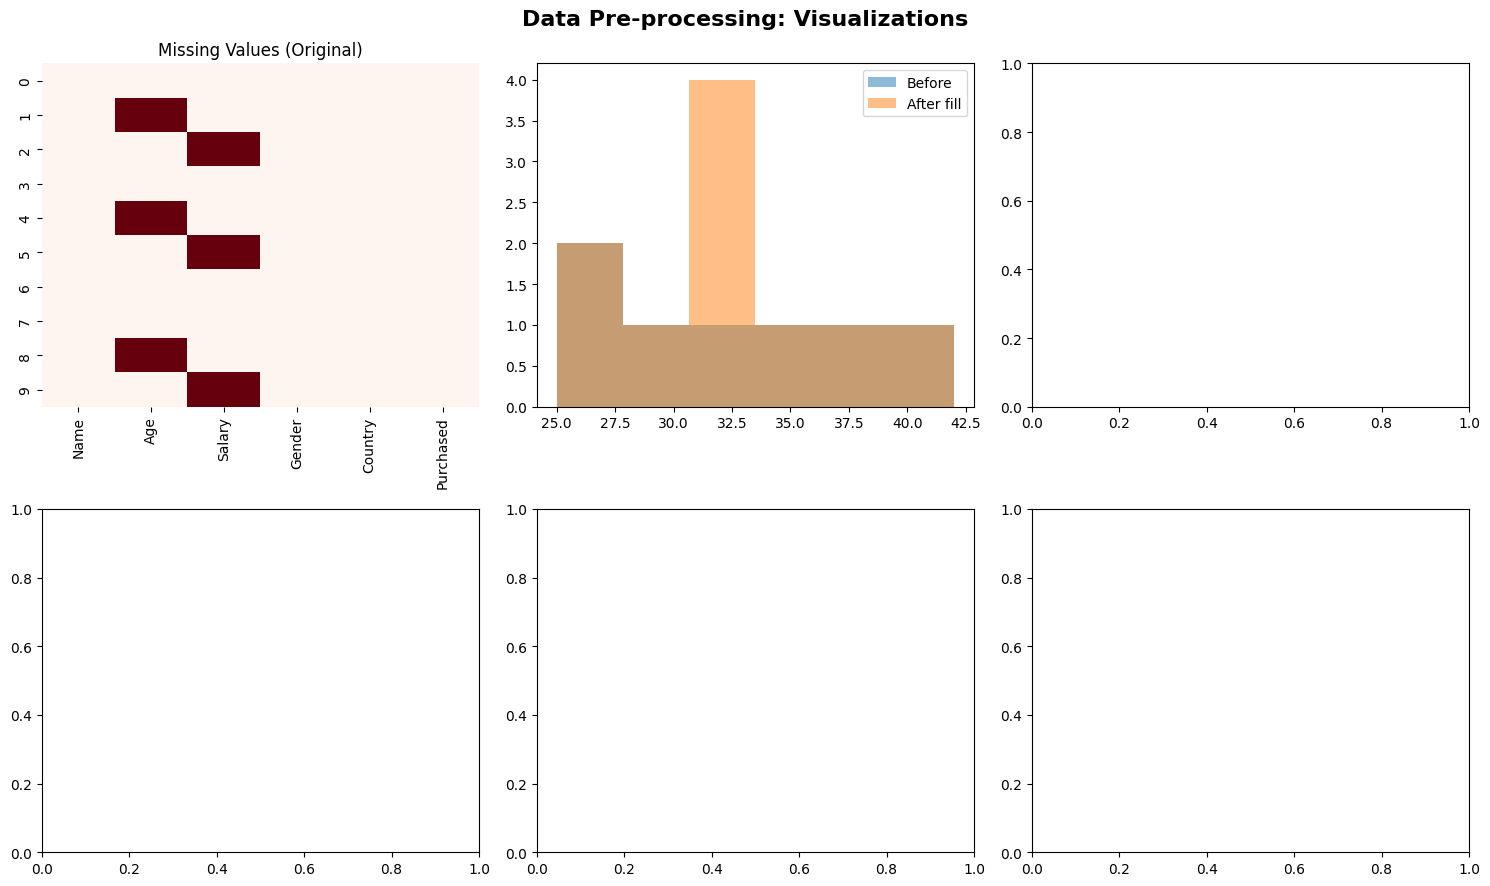

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Data Pre-processing: Visualizations", fontsize=16, fontweight='bold')
 
# 1. Missing values heatmap
sns.heatmap(orig_missing.isnull(), ax=axes[0,0], cbar=False, cmap='Reds')
axes[0,0].set_title("Missing Values (Original)")
 
# 2. Age distribution comparison
axes[0,1].hist([25,35,28,42,31,26,38], bins=6, alpha=0.5, label='Before')
axes[0,1].hist(df['Age'], bins=6, alpha=0.5, label='After fill')
axes[0,1].legend()
 
# (and 4 more subplots...)
plt.tight_layout()
plt.show()
